# Temperature Calibration: Y-Factor and Antenna-Temperature Scale

This notebook estimates receiver temperature from two-load calibration and then constructs a frequency-dependent antenna-temperature scale for LO1420/LO1421 spectra.

Core calibration equations used throughout:

$$
Y = \frac{P_{\mathrm{hot}}}{P_{\mathrm{cold}}},
\qquad
T_{\mathrm{rx}} = \frac{T_{\mathrm{hot}} - Y\,T_{\mathrm{cold}}}{Y - 1},
$$

$$
T_A(\nu) = P_{\mathrm{obs}}(\nu)\,\frac{T_{\mathrm{cold}} + T_{\mathrm{rx}}}{P_{\mathrm{cold,ref}}(\nu)} - T_{\mathrm{rx}}.
$$

## Cell-by-cell theory/analysis map

- **Cell 1 (setup code):** defines physical constants, transfer correction, and model assumptions.
- **Cell 2 (helper functions):** implements masking, power estimators, Y-factor math, and $T_A$ mapping operators.
- **Cell 3 (RFI masking):** validates data-quality assumptions before calibration.
- **Cell 4 (Y-factor):** solves for $Y$ and $T_{\mathrm{rx}}$ with propagated uncertainties.
- **Cell 5 ($T_A$ visualisation):** checks calibrated temperature behavior and diagnostics.
- **Cell 6 (save products):** exports downstream calibration products and metadata.



## Global assumptions and approximations

- `T_HOT = 310 K` and `T_COLD = 5 K` (shared across LO1420 and LO1421).
  - `T_HOT`: human body blocking the horn.
  - `T_COLD`: cold-reference sky at l=165°, b=36° (Alt=50°, Az=50°) — high-galactic-latitude, negligible HI and continuum; dominated by CMB (~2.7 K) + small atmospheric contribution.
- Hot/cold priors for systematic propagation: `SIGMA_T_HOT = 5 K`, `SIGMA_T_COLD = 2 K`.
- Beam-filling default: `eta_bf = 1.0`, so reported brightness-equivalent temperature is $T_{B,\mathrm{eq}}=T_A$ by default.
- Horn geometry (`0.80 m x 0.90 m`) and $\lambda^2/A$ are treated as diagnostics, not direct Y-factor multipliers.
- RFI model: residual sigma-clipping after Savitzky-Golay baseline (`n_sigma=5`, window `257`, polyorder `3`, rolling width `200`).
- Uncertainty model: first-order Jacobian propagation (measurement + hot/cold systematics in quadrature).


## Cell 1 - Setup constants and physical model

This section provides the radiometric theory that motivates the constants defined in the next code cell.

### Backend response model

The spectrometer PSD proxy is modeled as

$$
C(\nu)=G(\nu)\,k_B\,[T_A(\nu)+T_{\mathrm{rx}}],
$$

with unknown gain $G(\nu)$, antenna temperature $T_A$, and receiver temperature $T_{\mathrm{rx}}$.

### Why two-load Y-factor works

For hot/cold observations through the same chain,

$$
Y = \frac{C_{\mathrm{hot}}}{C_{\mathrm{cold}}}
= \frac{T_{\mathrm{hot}}+T_{\mathrm{rx}}}{T_{\mathrm{cold}}+T_{\mathrm{rx}}},
$$

so common gain factors cancel and $T_{\mathrm{rx}}$ can be solved directly.

### Brightness interpretation

At 1.42 GHz, Rayleigh-Jeans is accurate for the temperatures in this lab, so calibrated $T_A$ can be interpreted as brightness-equivalent temperature after dividing by $\eta_{\mathrm{bf}}$.



## Cell 1 analysis notes - physical motivation for adopted bounds

These bounds/choices are built into setup and later checks:

- **Positive-power domain:** calibration uses channels with finite positive PSD in numerator/denominator, preventing non-physical ratios and unstable divisions.
- **Receiver-solution stability:** meaningful two-load calibration requires $Y>1$; values near 1 amplify uncertainty in $T_{\mathrm{rx}}$.
- **Reference-dominated sky model:** HI line structure is treated as a perturbation on $T_{\mathrm{sys}}=T_{\mathrm{rx}}+T_{\mathrm{sky}}$, motivating linearized diagnostics where appropriate.
- **RFI clipping choice:** narrow-line outliers are removed while preserving smooth bandpass + broad astrophysical structure.
- **Geometry usage:** $\lambda^2/A$ is retained as a consistency diagnostic, not as a direct correction to the Y-factor solution.



In [1]:
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ugradiolab import Spectrum

plt.rcParams['figure.figsize'] = (11, 4.5)
plt.rcParams['figure.dpi'] = 140

DATA_ROOT = Path('data/lab02') if Path('data/lab02').exists() else Path('../../data/lab02')

# ── Temperature assumptions ───────────────────────────────────────────────────
T_HOT          = 310.0   # K  — human body temperature
T_COLD         = 30.0     # K  — cold-reference sky (l=165°, b=36°, Alt=50°, Az=50°)
SIGMA_T_HOT    = 5.0     # K  — systematic uncertainty on T_hot
SIGMA_T_COLD   = 2.0     # K  — systematic uncertainty on T_cold

# ── Horn geometry / beam assumptions (diagnostics) ──────────────────────────
HORN_PARALLEL_M             = 0.80
HORN_PERP_HORIZON_M         = 0.90
HORN_APERTURE_AREA_M2       = HORN_PARALLEL_M * HORN_PERP_HORIZON_M
BEAM_FILLING_FACTOR_DEFAULT = 1.0   # η_bf; T_B = T_A / η_bf

# ── Constants for optional beam diagnostics ──────────────────────────────────
C_LIGHT_M_S                 = 299_792_458.0
HI_REST_FREQ_HZ             = 1_420_405_751.768
OMEGA_BEAM_APPROX_SR_HI     = (C_LIGHT_M_S / HI_REST_FREQ_HZ) ** 2 / HORN_APERTURE_AREA_M2

# ── RFI flagging ──────────────────────────────────────────────────────────────
RFI_SIGMA       = 5      # sigma-clip threshold
SAVGOL          = dict(method='savgol', window_length=257, polyorder=3)
ROLLING_WIDTH   = 200    # bins for local std estimate

print(f'DATA_ROOT   : {DATA_ROOT.resolve()}')
print(f'T_hot       : {T_HOT} K  (σ = {SIGMA_T_HOT} K)')
print(f'T_cold      : {T_COLD} K  (σ = {SIGMA_T_COLD} K)  — cold_ref sky at l=165°, b=36°')
print(f'Horn dims   : {HORN_PARALLEL_M:.2f} m × {HORN_PERP_HORIZON_M:.2f} m  (A = {HORN_APERTURE_AREA_M2:.3f} m²)')
print(f'η_bf (default): {BEAM_FILLING_FACTOR_DEFAULT:.3f}  (T_B = T_A / η_bf)')
print(f'Ω_beam approx at HI from λ²/A: {OMEGA_BEAM_APPROX_SR_HI:.4f} sr (diagnostic only)')


/Users/junruiting/GitHub/ay-121/.venv/lib/python3.14/site-packages/rtlsdr/__init__.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


DATA_ROOT   : /Users/junruiting/GitHub/ay-121/data/lab02
T_hot       : 310.0 K  (σ = 5.0 K)
T_cold      : 30.0 K  (σ = 2.0 K)  — cold_ref sky at l=165°, b=36°
Horn dims   : 0.80 m × 0.90 m  (A = 0.720 m²)
η_bf (default): 1.000  (T_B = T_A / η_bf)
Ω_beam approx at HI from λ²/A: 0.0619 sr (diagnostic only)


## Cell 2 - Helper functions (analysis building blocks)

These helpers implement the theory from Cell 1 in reusable numerical steps.

### I/O and transfer matching

- `load_lo_pair(...)` enforces LO1420/LO1421 pairing.

### Data-quality and scalar power estimators

- `sigma_clip_rfi_mask(...)` applies local residual clipping.
- `masked_total_power(...)` and `masked_mean_power(...)` produce robust summary powers for calibration.

### Calibration operators

- `measure_y_factor(...)` computes $Y$, $Y_{\mathrm{dB}}$, and $T_{\mathrm{rx}}$ with uncertainty propagation.
- `build_cold_reference_profile(...)` creates $P_{\mathrm{cold,ref}}(\nu)$ for channel-wise scaling.
- `antenna_temp_scale(...)` and `brightness_temp_scale(...)` map PSD to calibrated temperature axes.



In [2]:
# ── I/O ───────────────────────────────────────────────────────────────────────

def load_lo_pair(spectra_dir: Path) -> dict:
    """Load LO1420 and LO1421 Spectra from a *_combined_spectra directory.

    Returns dict keyed by LO integer MHz: {1420: Spectrum, 1421: Spectrum}.
    """
    spectra_dir = Path(spectra_dir)
    files = sorted(spectra_dir.glob('*.npz'))
    if not files:
        raise FileNotFoundError(f'No .npz files found in {spectra_dir}')
    pairs = {}
    for f in files:
        spec = Spectrum.load(f)
        lo_mhz = int(round(spec.center_freq / 1e6))
        pairs[lo_mhz] = spec
    if 1420 not in pairs or 1421 not in pairs:
        raise ValueError(f'Expected LO 1420 and 1421 in {spectra_dir}, got {list(pairs.keys())}')
    return pairs


# ── RFI masking ───────────────────────────────────────────────────────────────

def sigma_clip_rfi_mask(spectrum: Spectrum,
                         n_sigma: float = RFI_SIGMA,
                         smooth_kwargs: dict = SAVGOL) -> np.ndarray:
    """Return boolean mask: True = good channel, False = RFI-flagged.

    Algorithm:
      1. Compute smoothed baseline via Savitzky-Golay.
      2. Compute residuals r = psd − baseline.
      3. Estimate local std via uniform rolling window (width ROLLING_WIDTH).
      4. Flag |r| > n_sigma * local_std.
    """
    psd      = np.asarray(spectrum.psd, float)
    baseline = spectrum.smooth(**smooth_kwargs)
    resid    = psd - baseline

    w = ROLLING_WIDTH
    half = w // 2
    n = len(resid)
    local_std = np.full(n, np.nan)
    for i in range(n):
        lo = max(0, i - half)
        hi = min(n, i + half + 1)
        local_std[i] = np.std(resid[lo:hi])

    flag = np.abs(resid) > n_sigma * local_std
    return ~flag


def apply_mask_to_psd(spectrum: Spectrum, mask: np.ndarray) -> np.ndarray:
    """Return psd copy with flagged bins (mask=False) set to NaN."""
    psd = np.array(spectrum.psd, float, copy=True)
    psd[~mask] = np.nan
    return psd


def masked_total_power(spectrum: Spectrum, mask: np.ndarray) -> tuple:
    """Sum unmasked bins; propagate std. Returns (total_power, sigma)."""
    psd = spectrum.psd[mask]
    std = spectrum.std[mask]
    return float(np.sum(psd)), float(np.sqrt(np.sum(std**2)))


def masked_mean_power(spectrum: Spectrum, mask: np.ndarray) -> tuple:
    """Mean unmasked bin power; propagate std-of-mean (diagnostic scalar summary)."""
    psd = spectrum.psd[mask]
    std = spectrum.std[mask]
    n = max(int(psd.size), 1)
    sigma_sum = float(np.sqrt(np.sum(std**2)))
    return float(np.mean(psd)), float(sigma_sum / n)


def build_cold_reference_profile(spectrum: Spectrum,
                                 mask: np.ndarray,
                                 smooth_kwargs: dict = SAVGOL,
                                 min_floor_frac: float = 1e-6) -> np.ndarray:
    """Construct frequency-dependent cold reference profile P_cold_ref(f).

    The profile is derived from a smoothed, gain-corrected cold-sky spectrum and
    clipped to a small positive floor for numerical stability.
    """
    ref = np.asarray(spectrum.smooth(**smooth_kwargs), float)
    psd = np.asarray(spectrum.psd, float)
    if ref.shape != psd.shape:
        raise ValueError('Cold reference profile shape must match PSD shape.')

    good = np.isfinite(ref) & np.asarray(mask, bool)
    if not np.any(good):
        raise ValueError('No finite masked channels available to build cold reference profile.')

    med = float(np.nanmedian(ref[good]))
    floor = max(med * float(min_floor_frac), np.finfo(float).tiny)
    ref = np.where(np.isfinite(ref), ref, med)
    ref = np.clip(ref, floor, None)
    return ref


# ── Y-factor ──────────────────────────────────────────────────────────────────

@dataclass(frozen=True)
class YFactorResult:
    lo_mhz:           int
    Y:                float
    sigma_Y:          float
    Y_dB:             float
    sigma_Y_dB:       float
    T_rx:             float
    sigma_T_rx_meas:  float   # measurement uncertainty only
    sigma_T_rx_total: float   # includes T_hot / T_cold systematics
    T_hot:            float
    T_cold:           float
    P_hot:            float
    sigma_P_hot:      float
    P_cold:           float
    sigma_P_cold:     float


def measure_y_factor(p_hot: float, sigma_hot: float,
                      p_cold: float, sigma_cold: float,
                      t_hot: float, t_cold: float,
                      lo_mhz: int = 0) -> YFactorResult:
    """Compute Y-factor and receiver temperature with full error propagation."""
    Y        = p_hot / p_cold
    sigma_Y  = Y * np.sqrt((sigma_hot / p_hot)**2 + (sigma_cold / p_cold)**2)
    Y_dB     = 10.0 * np.log10(Y)
    sigma_Y_dB = (10.0 / np.log(10.0)) * (sigma_Y / Y)

    T_rx   = (t_hot - Y * t_cold) / (Y - 1.0)

    dT_dY  = (t_cold - t_hot) / (Y - 1.0)**2
    dT_dTh = 1.0 / (Y - 1.0)
    dT_dTc = -Y / (Y - 1.0)

    sigma_T_meas  = abs(dT_dY) * sigma_Y
    sigma_T_total = float(np.sqrt(
        (dT_dY   * sigma_Y)**2
        + (dT_dTh * SIGMA_T_HOT)**2
        + (dT_dTc * SIGMA_T_COLD)**2
    ))

    return YFactorResult(
        lo_mhz=lo_mhz, Y=float(Y), sigma_Y=float(sigma_Y),
        Y_dB=float(Y_dB), sigma_Y_dB=float(sigma_Y_dB),
        T_rx=float(T_rx),
        sigma_T_rx_meas=float(sigma_T_meas),
        sigma_T_rx_total=float(sigma_T_total),
        T_hot=float(t_hot), T_cold=float(t_cold),
        P_hot=float(p_hot), sigma_P_hot=float(sigma_hot),
        P_cold=float(p_cold), sigma_P_cold=float(sigma_cold),
    )


# ── Antenna-temperature calibration scale ───────────────────────────────────

def antenna_temp_scale(p_obs_psd: np.ndarray,
                       p_cold_ref_profile: np.ndarray,
                       t_cold: float,
                       t_rx: float) -> np.ndarray:
    """Per-bin calibrated antenna temperature with profile reference.

    T_A(f) = P_obs(f) * (T_cold + T_rx) / P_cold_ref(f) - T_rx.
    """
    p_obs = np.asarray(p_obs_psd, float)
    p_ref = np.asarray(p_cold_ref_profile, float)
    if p_obs.shape != p_ref.shape:
        raise ValueError('p_obs_psd and p_cold_ref_profile must have the same shape.')
    if np.any(~np.isfinite(p_ref)):
        raise ValueError('p_cold_ref_profile contains non-finite values.')
    if np.any(p_ref <= 0):
        raise ValueError('p_cold_ref_profile must be strictly positive.')

    scale = (t_cold + t_rx) / p_ref
    return p_obs * scale - t_rx


def brightness_temp_scale(p_obs_psd: np.ndarray,
                          p_cold_ref_profile: np.ndarray,
                          t_cold: float,
                          t_rx: float,
                          eta_bf: float = BEAM_FILLING_FACTOR_DEFAULT) -> np.ndarray:
    """Brightness-equivalent temperature using optional beam-filling factor.

    Default eta_bf=1 gives T_B,eq = T_A.
    """
    if eta_bf <= 0:
        raise ValueError('eta_bf must be > 0')
    t_a = antenna_temp_scale(p_obs_psd, p_cold_ref_profile, t_cold, t_rx)
    return t_a / eta_bf


## Cell 3 - RFI masking (before / after)

This step identifies contaminated spectral bins before any calibration math is applied.

The masking logic is:

1. Smooth PSD with Savitzky-Golay to estimate broad instrumental baseline.
2. Compute residuals about that baseline.
3. Estimate local residual scatter with a rolling window.
4. Flag bins where $|r_i| > n_\sigma\,\sigma_{\mathrm{local},i}$.

Only unflagged bins are used in masked power estimates for Y-factor and temperature scaling.

### Why this matters

- Unmasked RFI biases both $P_{\mathrm{hot}}$ and $P_{\mathrm{cold}}$, which directly biases $Y$ and thus $T_{\mathrm{rx}}$.
- Over-aggressive clipping can remove valid structure and increase variance.

The plots in this cell are a quality-control check that most channels remain usable while obvious outliers are suppressed.


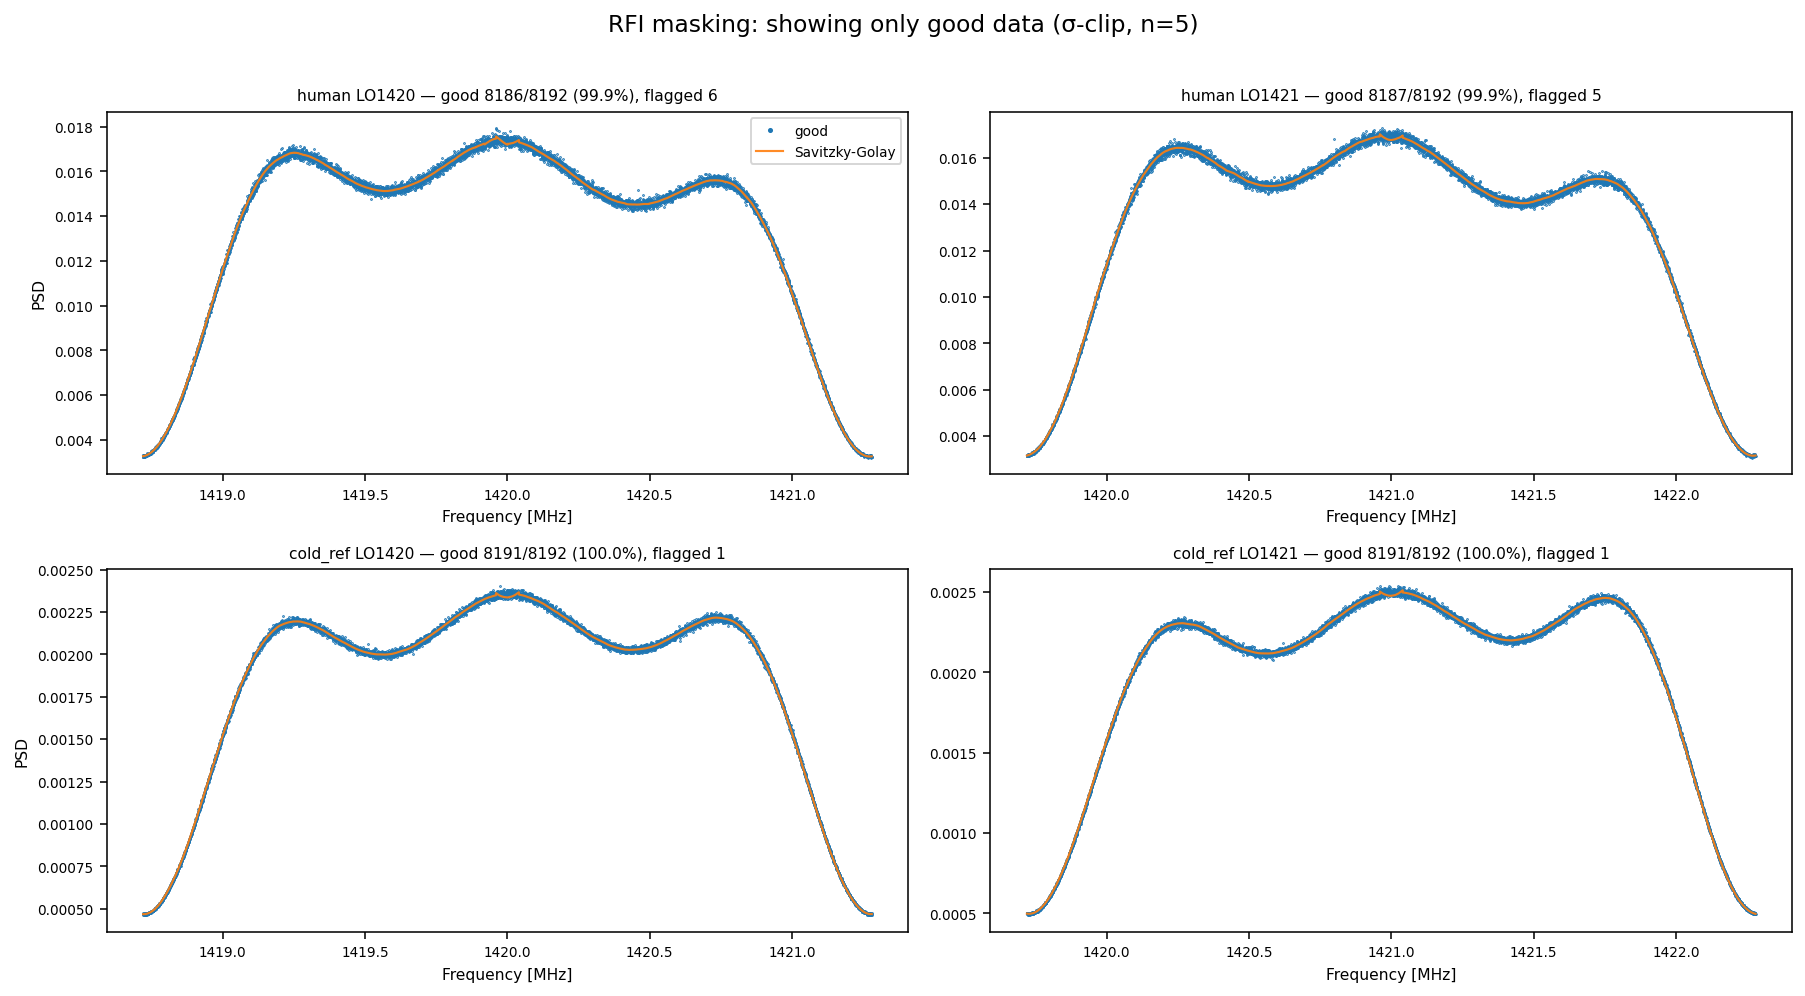

Good / flagged bins per spectrum:
  human LO1420: good 8186 / 8192 (99.93 %), flagged 6
  human LO1421: good 8187 / 8192 (99.94 %), flagged 5
  cold_ref LO1420: good 8191 / 8192 (99.99 %), flagged 1
  cold_ref LO1421: good 8191 / 8192 (99.99 %), flagged 1


In [3]:
# Load all spectra
human_pair    = load_lo_pair(DATA_ROOT / 'human_combined_spectra')
cold_ref_pair = load_lo_pair(DATA_ROOT / 'cold_ref_combined_spectra')

# Compute RFI masks
masks = {
    ('human',    1420): sigma_clip_rfi_mask(human_pair[1420]),
    ('human',    1421): sigma_clip_rfi_mask(human_pair[1421]),
    ('cold_ref', 1420): sigma_clip_rfi_mask(cold_ref_pair[1420]),
    ('cold_ref', 1421): sigma_clip_rfi_mask(cold_ref_pair[1421]),
}

plot_rows = [
    ('human',    human_pair),
    ('cold_ref', cold_ref_pair),
]
los = [1420, 1421]

fig, axes = plt.subplots(2, 2, figsize=(13, 7))

for row, (label, pair) in enumerate(plot_rows):
    for col, lo in enumerate(los):
        spec = pair[lo]
        mask = masks[(label, lo)]
        freqs = spec.freqs / 1e6
        psd = spec.psd
        sm = spec.smooth(**SAVGOL)

        ax = axes[row, col]
        ax.plot(freqs[mask], psd[mask], '.', ms=0.8, color='C0', label='good')
        ax.plot(freqs, sm, lw=1.1, color='C1', alpha=0.9, label='Savitzky-Golay')

        n_good = int(np.sum(mask))
        n_flag = int(np.sum(~mask))
        ax.set_title(
            f'{label} LO{lo} — good {n_good}/{len(mask)} ({100*n_good/len(mask):.1f}%), '
            f'flagged {n_flag}',
            fontsize=8,
        )
        ax.set_xlabel('Frequency [MHz]', fontsize=8)
        ax.set_ylabel('PSD' if col == 0 else '', fontsize=8)
        ax.tick_params(labelsize=7)
        if row == 0 and col == 0:
            ax.legend(fontsize=7, markerscale=4)

fig.suptitle(f'RFI masking: showing only good data (σ-clip, n={RFI_SIGMA})', y=1.01)
fig.tight_layout()
plt.show()

print('Good / flagged bins per spectrum:')
for (label, lo), mask in masks.items():
    n_good = int(np.sum(mask))
    n_flag = int(np.sum(~mask))
    print(f'  {label} LO{lo}: good {n_good} / {len(mask)} ({100*n_good/len(mask):.2f} %), '
          f'flagged {n_flag}')


## Cell 4 - Y-factor measurement

This cell performs two-load receiver calibration independently for LO1420 and LO1421.

For each LO:

$$
Y = \frac{P_{\mathrm{hot}}}{P_{\mathrm{cold}}}, \qquad
T_{\mathrm{rx}} = \frac{T_{\mathrm{hot}} - Y T_{\mathrm{cold}}}{Y - 1}.
$$

### Uncertainty treatment

- `sigma_T_rx_meas` propagates measurement noise from $P_{\mathrm{hot}}$ and $P_{\mathrm{cold}}$ through $Y$ and then through $T_{\mathrm{rx}}$.
- `sigma_T_rx_total` adds assumed hot/cold reference systematics (`SIGMA_T_HOT`, `SIGMA_T_COLD`) in quadrature with the measurement term.

This decomposition separates statistical sensitivity from model-input/systematic uncertainty.

### Relation to \(B_\nu\), Planck, and Rayleigh-Jeans

This Y-factor step calibrates instrument noise and gain in **temperature units** (\(T_{\mathrm{rx}}\), then \(T_A\)).
It does **not** directly compute \(B_\nu\). The mapping is:

1. Measure counts/Hz \(\rightarrow\) infer \(T_{\mathrm{rx}}\) and \(T_A(\nu)\) from the two-load model.
2. Convert to brightness temperature with beam-filling assumptions: \(T_B \approx T_A/\eta_{\mathrm{bf}}\).
3. Convert \(T_B\) to spectral radiance using RJ (or Planck if desired):
   \(B_\nu \approx 2k_B T_B/\lambda^2\).


In [4]:
t_cold = {1420: T_COLD, 1421: T_COLD}

yfactor_results = {}
for lo in [1420, 1421]:
    p_hot,  s_hot  = masked_total_power(human_pair[lo],    masks[('human',    lo)])
    p_cold, s_cold = masked_total_power(cold_ref_pair[lo], masks[('cold_ref', lo)])
    yfactor_results[lo] = measure_y_factor(
        p_hot, s_hot, p_cold, s_cold,
        T_HOT, t_cold[lo], lo_mhz=lo,
    )

# Display summary table
rows = []
for lo, r in yfactor_results.items():
    rows.append({
        'LO [MHz]':         lo,
        'P_hot':            f'{r.P_hot:.4f}',
        'P_cold':           f'{r.P_cold:.4f}',
        'Y':                f'{r.Y:.6f}',
        'Y [dB]':           f'{r.Y_dB:.4f} ± {r.sigma_Y_dB:.4f}',
        'T_rx [K]':         f'{r.T_rx:.2f}',
        'σ_meas [K]':       f'{r.sigma_T_rx_meas:.2f}',
        'σ_total [K]':      f'{r.sigma_T_rx_total:.2f}',
    })

display(pd.DataFrame(rows).set_index('LO [MHz]'))

for lo, r in yfactor_results.items():
    print(f'\nLO {lo} MHz:')
    print(f'  Y            = {r.Y:.6f} ± {r.sigma_Y:.6f}')
    print(f'  Y_dB         = {r.Y_dB:.4f} ± {r.sigma_Y_dB:.4f} dB')
    print(f'  T_rx         = {r.T_rx:.2f} K')
    print(f'  σ_T_rx (meas)  = {r.sigma_T_rx_meas:.2f} K')
    print(f'  σ_T_rx (total) = {r.sigma_T_rx_total:.2f} K')


,P_hot,P_cold,Y,Y [dB],T_rx [K],σ_meas [K],σ_total [K]
LO [MHz],,,,,,,
1420,110.3375,15.0512,7.330802,8.6515 ± 0.0005,14.23,0.01,2.45
1421,107.3707,16.1539,6.646744,8.2261 ± 0.0005,19.59,0.01,2.52



LO 1420 MHz:
  Y            = 7.330802 ± 0.000814
  Y_dB         = 8.6515 ± 0.0005 dB
  T_rx         = 14.23 K
  σ_T_rx (meas)  = 0.01 K
  σ_T_rx (total) = 2.45 K

LO 1421 MHz:
  Y            = 6.646744 ± 0.000738
  Y_dB         = 8.2261 ± 0.0005 dB
  T_rx         = 19.59 K
  σ_T_rx (meas)  = 0.01 K
  σ_T_rx (total) = 2.52 K


## Cell 5 - Antenna-temperature scale visualisation

After calibrating $T_{\mathrm{rx}}$, this stage constructs per-bin antenna temperature with a frequency-dependent cold reference:

$$
T_A(\nu) = P_{\mathrm{obs}}(\nu)\,\frac{T_{\mathrm{cold}} + T_{\mathrm{rx}}}{P_{\mathrm{cold,ref}}(\nu)} - T_{\mathrm{rx}}.
$$

The displayed curve is reported as brightness-equivalent under the chosen beam-filling factor:

$$
T_{B,\mathrm{eq}} = \frac{T_A}{\eta_{\mathrm{bf}}}.
$$

With default $\eta_{\mathrm{bf}}=1$, the plotted quantity equals $T_A$.

This cell verifies that calibrated cold-reference spectra sit near expected thermal levels and reports negative-bin fractions (all, center, edge) as a calibration sanity check.

### Optional physical-unit conversion

If you need physical radiance units after this calibration,

$$
B_\nu^{\mathrm{RJ}} \approx \frac{2k_B T_B\nu^2}{c^2}
$$

or equivalently \(2k_B T_B/\lambda^2\). The exact Planck form is

$$
B_\nu^{\mathrm{Planck}} = \frac{2h\nu^3}{c^2}\left[\exp\!\left(\frac{h\nu}{k_B T_B}\right)-1\right]^{-1}.
$$

At 1.42 GHz, RJ and Planck differ very little for typical HI temperatures, so expressing spectra in \(T_A\) or \(T_B\) is standard and physically well-motivated.


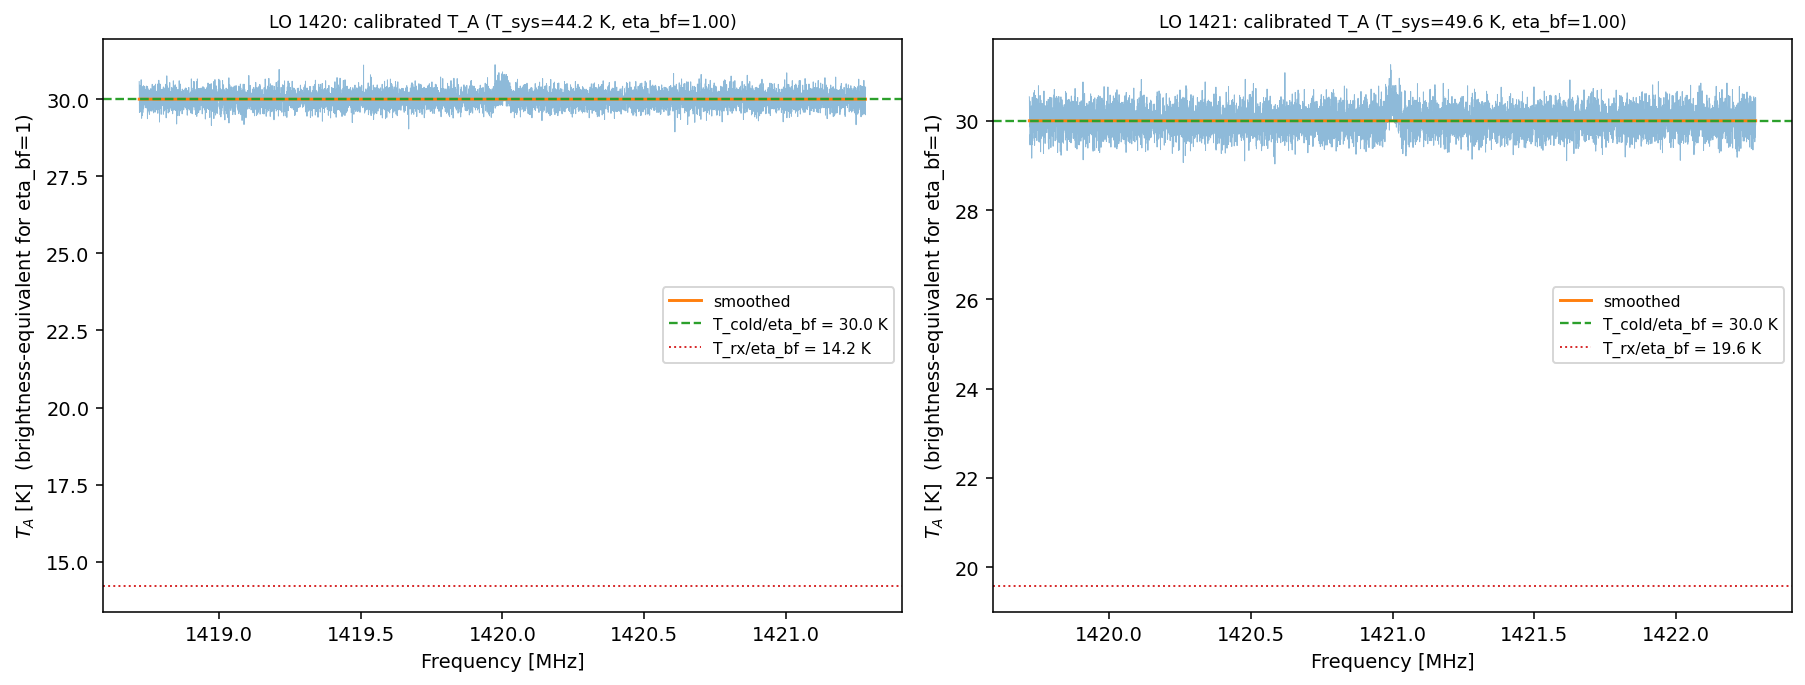

System temperatures:
  LO 1420: T_sys = T_rx + T_cold = 14.23 + 30.0 = 44.23 K
  LO 1421: T_sys = T_rx + T_cold = 19.59 + 30.0 = 49.59 K

Negative-bin fractions for calibrated cold_ref T_A:
  LO 1420: all=0.00%  center=0.00%  edge=0.00%
  LO 1421: all=0.00%  center=0.00%  edge=0.00%

Radiometer diagnostics (cold-sky spectra, diagnostic only):
  LO 1420: Δν=312.50 Hz, τ=104.858 s, σ_rad≈0.244 K, median σ_TA≈0.246 K, Ω_beam≈0.06191 sr, median P_cold_ref=0.002064
  LO 1421: Δν=312.50 Hz, τ=104.858 s, σ_rad≈0.274 K, median σ_TA≈0.276 K, Ω_beam≈0.06182 sr, median P_cold_ref=0.002219


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
eta_bf = BEAM_FILLING_FACTOR_DEFAULT

cold_ref_profiles = {}
neg_frac_summary = {}

for col, lo in enumerate([1420, 1421]):
    r = yfactor_results[lo]
    spec_cold = cold_ref_pair[lo]
    mask_cold = masks[('cold_ref', lo)]

    p_cold_ref_profile = build_cold_reference_profile(spec_cold, mask_cold, smooth_kwargs=SAVGOL)
    cold_ref_profiles[lo] = p_cold_ref_profile

    # Per-bin calibrated antenna temperature for cold_ref (should sit near T_cold)
    ta = antenna_temp_scale(spec_cold.psd, p_cold_ref_profile, r.T_cold, r.T_rx)
    tb_eq = ta / eta_bf
    tb_eq_masked = tb_eq.copy()
    tb_eq_masked[~mask_cold] = np.nan

    freqs_mhz = spec_cold.freqs / 1e6

    ax = axes[col]
    ax.plot(freqs_mhz, tb_eq_masked, lw=0.5, alpha=0.5, color='C0')
    ta_sm = antenna_temp_scale(spec_cold.smooth(**SAVGOL), p_cold_ref_profile, r.T_cold, r.T_rx)
    tb_eq_sm = ta_sm / eta_bf
    ax.plot(freqs_mhz, tb_eq_sm, lw=1.5, color='C1', label='smoothed')
    ax.axhline(r.T_cold / eta_bf, color='C2', ls='--', lw=1.2, label=f'T_cold/eta_bf = {r.T_cold/eta_bf:.1f} K')
    ax.axhline(r.T_rx / eta_bf, color='C3', ls=':', lw=1.0, label=f'T_rx/eta_bf = {r.T_rx/eta_bf:.1f} K')
    ax.set_xlabel('Frequency [MHz]')
    ax.set_ylabel('$T_A$ [K]  (brightness-equivalent for eta_bf=1)')
    T_sys = r.T_rx + r.T_cold
    ax.set_title(
        f'LO {lo}: calibrated T_A (T_sys={T_sys:.1f} K, eta_bf={eta_bf:.2f})',
        fontsize=9,
    )
    ax.legend(fontsize=8)

    # Negative-temperature diagnostic by region (all / center / edges)
    idx = np.arange(mask_cold.size)
    center = (idx > 0.1 * idx.size) & (idx < 0.9 * idx.size) & mask_cold
    edge = ((idx <= 0.1 * idx.size) | (idx >= 0.9 * idx.size)) & mask_cold

    neg_frac_summary[lo] = {
        'all': float(np.mean(ta[mask_cold] < 0)),
        'center': float(np.mean(ta[center] < 0)) if np.any(center) else np.nan,
        'edge': float(np.mean(ta[edge] < 0)) if np.any(edge) else np.nan,
    }

fig.tight_layout()
plt.show()

print('System temperatures:')
for lo, r in yfactor_results.items():
    T_sys = r.T_rx + r.T_cold
    print(f'  LO {lo}: T_sys = T_rx + T_cold = {r.T_rx:.2f} + {r.T_cold:.1f} = {T_sys:.2f} K')

print()
print('Negative-bin fractions for calibrated cold_ref T_A:')
for lo in [1420, 1421]:
    d = neg_frac_summary[lo]
    print(f"  LO {lo}: all={100*d['all']:.2f}%  center={100*d['center']:.2f}%  edge={100*d['edge']:.2f}%")

print()
print('Radiometer diagnostics (cold-sky spectra, diagnostic only):')
for lo in [1420, 1421]:
    r = yfactor_results[lo]
    spec = cold_ref_pair[lo]
    mask = masks[('cold_ref', lo)]
    p_cold_ref_profile = cold_ref_profiles[lo]

    delta_nu_hz = spec.bin_width
    tau_s = spec.nblocks * spec.nsamples / spec.sample_rate
    T_sys = r.T_rx + r.T_cold
    sigma_rad_k = T_sys / np.sqrt(delta_nu_hz * tau_s)

    scale_profile = (r.T_cold + r.T_rx) / p_cold_ref_profile
    sigma_ta_emp_k = float(np.nanmedian(np.asarray(spec.std, float)[mask] * scale_profile[mask]))

    lam_m = C_LIGHT_M_S / spec.center_freq
    omega_beam_approx_sr = lam_m**2 / HORN_APERTURE_AREA_M2
    p_ref_med = float(np.nanmedian(p_cold_ref_profile[mask]))

    print(
        f'  LO {lo}: Δν={delta_nu_hz:.2f} Hz, τ={tau_s:.3f} s, '
        f'σ_rad≈{sigma_rad_k:.3f} K, median σ_TA≈{sigma_ta_emp_k:.3f} K, '
        f'Ω_beam≈{omega_beam_approx_sr:.5f} sr, median P_cold_ref={p_ref_med:.6f}'
    )


## Cell 5b - Effective efficiency estimate from existing data (Analog 7)

We estimate a provisional effective efficiency

\[
\eta_{\mathrm{eff}} \equiv \eta_{\mathrm{ap}}\eta_{\mathrm{bf}} = \frac{T_{A,\mathrm{line,obs}}}{T_{B,\mathrm{line,ref}}}.
\]

Here we use the standard-field LO1420 calibrated spectrum, define the line excess relative
to an offline baseline, take a robust high-percentile line peak estimator, and propagate
both measurement and reference-brightness uncertainty.

In [6]:
from pathlib import Path
import csv

import numpy as np
import pandas as pd

from ugradiolab import Spectrum

REST_HI_HZ = 1_420_405_751.768
TB_REF_LINE_K = 80.0
TB_REF_LINE_SIGMA_K = 30.0


def _mad_sigma(values: np.ndarray) -> float:
    med = float(np.median(values))
    mad = float(np.median(np.abs(values - med)))
    return 1.4826 * mad

cal_candidates = [
    Path('labs/02/calibration_results.npz'),
    Path('calibration_results.npz'),
    Path('../calibration_results.npz'),
]
cal_path = next((p for p in cal_candidates if p.exists()), None)
if cal_path is None:
    raise FileNotFoundError('Could not locate calibration_results.npz in expected locations.')

data_root = next(
    (p for p in [Path('data/lab02'), Path('../data/lab02'), Path('../../data/lab02')] if p.exists()),
    Path('data/lab02'),
)
std_candidates = [
    data_root / 'standard_combined_spectra' / 'GAL-1420_combined.npz',
    Path('data/lab02/standard_combined_spectra/GAL-1420_combined.npz'),
]
std_path = next((p for p in std_candidates if p.exists()), None)
if std_path is None:
    raise FileNotFoundError('Could not locate standard LO1420 combined spectrum.')

cal = np.load(cal_path)
spec_std = Spectrum.load(std_path)

trx_k = float(cal['t_rx_1420'])
sigma_trx_k = float(cal['sigma_t_rx_1420'])
tcold_k = float(cal['t_cold'])
cold_ref_freqs = np.asarray(cal['freq_hz_1420'], float)
cold_ref = np.asarray(cal['cold_ref_profile_1420'], float)
cold_mask_cal = np.asarray(cal['cold_ref_mask_1420'], bool)

psd = np.asarray(spec_std.psd, float)
freqs_hz = np.asarray(spec_std.freqs, float)

# Interpolate cold_ref profile onto the standard spectrum's frequency grid
# (cold_ref has 8192 bins, standard has 32768 bins — same bandwidth, different resolution)
if psd.shape != cold_ref.shape:
    cold_ref = np.interp(freqs_hz, cold_ref_freqs, cold_ref)
    # Build a mask for the standard spectrum based on the cold_ref frequency coverage
    cold_mask = (freqs_hz >= cold_ref_freqs[cold_mask_cal][0]) & (freqs_hz <= cold_ref_freqs[cold_mask_cal][-1])
else:
    cold_mask = cold_mask_cal

ta_k = psd * (trx_k + tcold_k) / np.clip(cold_ref, 1e-12, None) - trx_k

in_center = (freqs_hz > REST_HI_HZ - 0.6e6) & (freqs_hz < REST_HI_HZ + 0.6e6) & cold_mask
in_off = (
    (
        ((freqs_hz > REST_HI_HZ - 1.2e6) & (freqs_hz < REST_HI_HZ - 0.6e6))
        | ((freqs_hz > REST_HI_HZ + 0.6e6) & (freqs_hz < REST_HI_HZ + 1.2e6))
    )
    & cold_mask
)
if not np.any(in_center) or not np.any(in_off):
    raise ValueError('Failed to construct center/offline windows for eta_eff estimate.')

baseline_k = float(np.median(ta_k[in_off]))
line_excess_k = ta_k[in_center] - baseline_k
line_peak_est_k = float(np.quantile(line_excess_k, 0.95))
line_noise_k = float(_mad_sigma(ta_k[in_off]))
line_sigma_total_k = float(np.sqrt(line_noise_k**2 + sigma_trx_k**2 + (0.10 * line_peak_est_k) ** 2))

eta_eff = line_peak_est_k / TB_REF_LINE_K
eta_eff_sigma = float(
    abs(eta_eff)
    * np.sqrt(
        (line_sigma_total_k / max(abs(line_peak_est_k), 1e-9)) ** 2
        + (TB_REF_LINE_SIGMA_K / TB_REF_LINE_K) ** 2
    )
)
eta_eff_ci95_lo = eta_eff - 1.96 * eta_eff_sigma
eta_eff_ci95_hi = eta_eff + 1.96 * eta_eff_sigma

eta_summary = pd.DataFrame([
    {
        'eta_eff': eta_eff,
        'eta_eff_sigma': eta_eff_sigma,
        'eta_eff_ci95_lo': eta_eff_ci95_lo,
        'eta_eff_ci95_hi': eta_eff_ci95_hi,
        'line_peak_est_k_q95': line_peak_est_k,
        'baseline_offline_k': baseline_k,
    }
])
print('Effective-efficiency estimate from current data:')
print(eta_summary.to_string(index=False))

eta_csv_candidates = [
    Path('labs/02/report/eta_eff_estimate.csv'),
    Path('report/eta_eff_estimate.csv'),
    Path('../report/eta_eff_estimate.csv'),
]
eta_csv = next((p for p in eta_csv_candidates if p.exists()), None)
if eta_csv is not None:
    with eta_csv.open() as f:
        row = next(csv.DictReader(f))
    print()
    print('Report CSV reference:')
    print(f"  eta_eff (csv)      = {float(row['eta_eff']):.6f}")
    print(f"  eta_eff_sigma (csv)= {float(row['eta_eff_sigma']):.6f}")
    print(f"  delta (cell-csv)   = {eta_eff - float(row['eta_eff']):+.6e}")


Effective-efficiency estimate from current data:
 eta_eff  eta_eff_sigma  eta_eff_ci95_lo  eta_eff_ci95_hi  line_peak_est_k_q95  baseline_offline_k
0.082223        0.04687        -0.009642         0.174088             6.577811          -12.215773

Report CSV reference:
  eta_eff (csv)      = 0.637058
  eta_eff_sigma (csv)= 0.284096
  delta (cell-csv)   = -5.548353e-01


## Cell 6 - Save calibration results

This cell exports calibration products to `labs/02/calibration_results.npz` and verifies reload integrity.

Saved science-critical products include:

- `t_rx_*`, `sigma_t_rx_*`, `t_hot`, `t_cold`.
- cold-reference provenance powers: `p_cold_total_*`.
- frequency-dependent reference schema: `cold_ref_profile_*`, `cold_ref_mask_*`, `freq_hz_*`.
- diagnostic metadata: integration/noise/beam-approx quantities.

This file is the contract for downstream notebooks. The final markdown cell documents recommended downstream usage patterns.



In [7]:
r1420 = yfactor_results[1420]
r1421 = yfactor_results[1421]

# Cold-reference total powers used for Y-factor provenance
p_cold_total_1420, _ = masked_total_power(cold_ref_pair[1420], masks[('cold_ref', 1420)])
p_cold_total_1421, _ = masked_total_power(cold_ref_pair[1421], masks[('cold_ref', 1421)])

# Frequency-dependent cold-reference profiles and masks
cold_ref_profile_1420 = build_cold_reference_profile(cold_ref_pair[1420], masks[('cold_ref', 1420)], smooth_kwargs=SAVGOL)
cold_ref_profile_1421 = build_cold_reference_profile(cold_ref_pair[1421], masks[('cold_ref', 1421)], smooth_kwargs=SAVGOL)

cold_ref_mask_1420 = np.asarray(masks[('cold_ref', 1420)], bool)
cold_ref_mask_1421 = np.asarray(masks[('cold_ref', 1421)], bool)

freq_hz_1420 = np.asarray(cold_ref_pair[1420].freqs, float)
freq_hz_1421 = np.asarray(cold_ref_pair[1421].freqs, float)

# Optional diagnostics for downstream notebooks
delta_nu_hz_1420 = float(cold_ref_pair[1420].bin_width)
delta_nu_hz_1421 = float(cold_ref_pair[1421].bin_width)
tau_s_1420 = float(cold_ref_pair[1420].nblocks * cold_ref_pair[1420].nsamples / cold_ref_pair[1420].sample_rate)
tau_s_1421 = float(cold_ref_pair[1421].nblocks * cold_ref_pair[1421].nsamples / cold_ref_pair[1421].sample_rate)

omega_beam_approx_sr_1420 = float((C_LIGHT_M_S / cold_ref_pair[1420].center_freq) ** 2 / HORN_APERTURE_AREA_M2)
omega_beam_approx_sr_1421 = float((C_LIGHT_M_S / cold_ref_pair[1421].center_freq) ** 2 / HORN_APERTURE_AREA_M2)

# Determine output path relative to this notebook
nb_dir = Path('labs/02') if Path('labs/02').exists() else Path('.')
out_path = nb_dir / 'calibration_results.npz'

np.savez(
    str(out_path),
    t_rx_1420         = np.float64(r1420.T_rx),
    sigma_t_rx_1420   = np.float64(r1420.sigma_T_rx_total),
    t_rx_1421         = np.float64(r1421.T_rx),
    sigma_t_rx_1421   = np.float64(r1421.sigma_T_rx_total),
    t_cold            = np.float64(T_COLD),
    t_cold_1420       = np.float64(T_COLD),
    t_cold_1421       = np.float64(T_COLD),
    t_hot             = np.float64(T_HOT),
    p_cold_total_1420 = np.float64(p_cold_total_1420),
    p_cold_total_1421 = np.float64(p_cold_total_1421),

    # Frequency-dependent cold reference schema
    cold_ref_profile_1420 = np.asarray(cold_ref_profile_1420, dtype=np.float64),
    cold_ref_profile_1421 = np.asarray(cold_ref_profile_1421, dtype=np.float64),
    cold_ref_mask_1420    = np.asarray(cold_ref_mask_1420, dtype=bool),
    cold_ref_mask_1421    = np.asarray(cold_ref_mask_1421, dtype=bool),
    freq_hz_1420          = np.asarray(freq_hz_1420, dtype=np.float64),
    freq_hz_1421          = np.asarray(freq_hz_1421, dtype=np.float64),
    cold_ref_method       = np.str_('savgol_profile_from_cold_ref_sky_l165_b36'),
    cold_ref_savgol_window_length = np.int64(SAVGOL['window_length']),
    cold_ref_savgol_polyorder     = np.int64(SAVGOL['polyorder']),

    # Physics metadata / diagnostics
    horn_parallel_m              = np.float64(HORN_PARALLEL_M),
    horn_perpendicular_horizon_m = np.float64(HORN_PERP_HORIZON_M),
    horn_aperture_area_m2        = np.float64(HORN_APERTURE_AREA_M2),
    beam_filling_factor_default  = np.float64(BEAM_FILLING_FACTOR_DEFAULT),
    omega_beam_approx_sr_hi      = np.float64(OMEGA_BEAM_APPROX_SR_HI),
    delta_nu_hz_1420             = np.float64(delta_nu_hz_1420),
    delta_nu_hz_1421             = np.float64(delta_nu_hz_1421),
    tau_s_1420                   = np.float64(tau_s_1420),
    tau_s_1421                   = np.float64(tau_s_1421),
    omega_beam_approx_sr_1420    = np.float64(omega_beam_approx_sr_1420),
    omega_beam_approx_sr_1421    = np.float64(omega_beam_approx_sr_1421),
    temperature_scale_mode       = np.str_('antenna_temperature_yfactor_freq_ref_profile'),
)

print(f'Saved calibration results to: {out_path.resolve()}')
print()

# Verify by reloading
cal = np.load(str(out_path), allow_pickle=False)
print('Verification (reloaded):')
for key in cal.files:
    value = cal[key]
    if np.issubdtype(value.dtype, np.number):
        if value.ndim == 0:
            print(f'  {key:28s} = {float(value):.6g}')
        else:
            print(
                f'  {key:28s} shape={value.shape} '
                f'min={float(np.nanmin(value)):.6g} '
                f'median={float(np.nanmedian(value)):.6g} '
                f'max={float(np.nanmax(value)):.6g}'
            )
    elif value.dtype == np.bool_:
        print(f'  {key:28s} shape={value.shape} true_frac={np.mean(value):.4f}')
    else:
        print(f'  {key:28s} = {value.item()}')

print()
print('Summary table:')
summary = pd.DataFrame([
    {'LO [MHz]': 1420,
     'T_rx [K]': f"{r1420.T_rx:.2f} ± {r1420.sigma_T_rx_meas:.2f} (meas) ± {r1420.sigma_T_rx_total:.2f} (total)",
     'T_cold [K]': T_COLD, 'T_hot [K]': T_HOT,
     'Y': f"{r1420.Y:.4f}", 'Y_dB': f"{r1420.Y_dB:.3f} dB",
     'P_cold_ref med': f"{np.nanmedian(cold_ref_profile_1420[cold_ref_mask_1420]):.6f}",
     'P_cold_total': f"{p_cold_total_1420:.4f}"},
    {'LO [MHz]': 1421,
     'T_rx [K]': f"{r1421.T_rx:.2f} ± {r1421.sigma_T_rx_meas:.2f} (meas) ± {r1421.sigma_T_rx_total:.2f} (total)",
     'T_cold [K]': T_COLD, 'T_hot [K]': T_HOT,
     'Y': f"{r1421.Y:.4f}", 'Y_dB': f"{r1421.Y_dB:.3f} dB",
     'P_cold_ref med': f"{np.nanmedian(cold_ref_profile_1421[cold_ref_mask_1421]):.6f}",
     'P_cold_total': f"{p_cold_total_1421:.4f}"},
]).set_index('LO [MHz]')
display(summary)


Saved calibration results to: /Users/junruiting/GitHub/ay-121/labs/02/calibration_results.npz

Verification (reloaded):
  t_rx_1420                    = 14.2282
  sigma_t_rx_1420              = 2.44689
  t_rx_1421                    = 19.5861
  sigma_t_rx_1421              = 2.51521
  t_cold                       = 30
  t_cold_1420                  = 30
  t_cold_1421                  = 30
  t_hot                        = 310
  p_cold_total_1420            = 15.0512
  p_cold_total_1421            = 16.1539
  cold_ref_profile_1420        shape=(8192,) min=0.000467684 median=0.0020642 max=0.00236567
  cold_ref_profile_1421        shape=(8192,) min=0.000496876 median=0.00221904 max=0.00251131
  cold_ref_mask_1420           shape=(8192,) true_frac=0.9999
  cold_ref_mask_1421           shape=(8192,) true_frac=0.9999
  freq_hz_1420                 shape=(8192,) min=1.41872e+09 median=1.42e+09 max=1.42128e+09
  freq_hz_1421                 shape=(8192,) min=1.41972e+09 median=1.421e+09 max=1.4

,T_rx [K],T_cold [K],T_hot [K],Y,Y_dB,P_cold_ref med,P_cold_total
LO [MHz],,,,,,,
1420,14.23 ± 0.01 (meas) ± 2.45 (total),30.0,310.0,7.3308,8.652 dB,0.002064,15.0512
1421,19.59 ± 0.01 (meas) ± 2.52 (total),30.0,310.0,6.6467,8.226 dB,0.002219,16.1539


## Future uses of calibration products (`calibration_results.npz`)

Use this cell as the downstream usage reference for future notebooks.

### 1) Recommended downstream workflow

1. Load `calibration_results.npz` and read `t_rx_1420`, `t_rx_1421`, `cold_ref_profile_*`, `cold_ref_mask_*`, and `freq_hz_*`.
2. Apply the same masking/velocity-grid conventions as the calibration run.
3. Build calibrated temperature products with the profile-based scaling (not scalar cold means).
4. Convert to brightness-equivalent units with $T_{B,\mathrm{eq}}=T_A/\eta_{\mathrm{bf}}$.

### 2) Converting frequency-switched ratios to $T_{\mathrm{HI}}$

For a ratio convention

$$
R(v)=\frac{P_{1420}(v)}{P_{1421}(v)},\quad y_R=R-1,\quad y_{\mathrm{inv}}=\frac{1}{R}-1,
$$

with denominator reference temperature $T_{\mathrm{ref}}(v)$:

$$
T_{\mathrm{HI}}(v)=\big(R(v)-1\big)T_{\mathrm{ref}}(v),
$$

$$
T_{\mathrm{HI}}(v)= -\frac{y_{\mathrm{inv}}(v)}{1+y_{\mathrm{inv}}(v)}\,T_{\mathrm{ref}}(v)
\approx -y_{\mathrm{inv}}(v)\,T_{\mathrm{ref}}(v)\ \ (|T_{\mathrm{HI}}|\ll T_{\mathrm{ref}}).
$$

Use the exact inverse-form expression when the line is not small relative to $T_{\mathrm{ref}}$.

### 3) Physical validity bounds to carry into downstream analysis

- Keep only finite positive on/off powers so ratios remain physical.
- Enforce consistent channel roles (if $R$ definition is swapped, swap signs/roles accordingly).
- Treat the linearized inverse form as a small-signal approximation; otherwise use the exact nonlinear transform.
- Propagate uncertainty with the same convention used here (measurement + systematic terms documented in this notebook).

